In [44]:
import numpy as np

## Distance Metrics in Data Science

Before diving into complex dimensionality reduction, it is crucial to understand how we measure the "distance" or "similarity" between data points. In data science, features are represented as numbers in an n-dimensional space. We need mathematical ways to figure out if two data points are similar (close) or different (far).

### 1. Euclidean Distance
Euclidean distance is the straight-line distance between two points in Euclidean space. It is the most common use of distance (like measuring with a ruler).

**Formula:**
$$ d(A, B) = \sqrt{\sum_{i=1}^{n} (A_i - B_i)^2} $$

**Why it's needed:**
It's used in algorithms like **K-Means Clustering** and **K-Nearest Neighbors (KNN)** to group similar items together. However, it is sensitive to the scale of the data (which is why we standardize features before using it!) and suffers heavily in high dimensions (Curse of Dimensionality).

### 2. Cosine Similarity & Distance
Cosine similarity measures the *angle* between two vectors (data points), rather than the straight-line distance. It tells us if two vectors are pointing in the same direction, regardless of their magnitude (length).

**Formula for Cosine Similarity:**
$$ \text{Similarity}(A, B) = \frac{A \cdot B}{\|A\| \|B\|} = \frac{\sum (A_i \times B_i)}{\sqrt{\sum A_i^2} \times \sqrt{\sum B_i^2}} $$

**Cosine Distance** is simply $1 - \text{Cosine Similarity}$.

**Why it's needed:**
It is incredibly useful when the *magnitude* of the data doesn't matter, but the *pattern* does. For example, in **Natural Language Processing (NLP)** or **Recommendation Systems**, a document with 1000 words might be on the same topic as a document with 10 words. Euclidean distance would say they are very far apart, but Cosine similarity would recognize they are pointing in the same direction and classify them as highly similar.


In [45]:
# ── All distances on the same pair of points ──────────────────────────
A = np.array([1., 3., 5., 2.])
B = np.array([4., 1., 2., 6.])

print("Point A:", A)
print("Point B:", B)
print()

# Manual step through for Euclidean
print()
print("─── Euclidean: Step by Step ─────────────────────────────────")
diffs = A - B
print(f"  Differences:          {diffs}")
print(f"  Squared differences:  {diffs**2}")
print(f"  Sum of squares:       {np.sum(diffs**2):.4f}")
print(f"  √Sum:                 {np.sqrt(np.sum(diffs**2)):.4f}")

# Cosine
cos_sim = np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))
print()
print("─── Cosine Similarity ──────────────────────────────────────")
print(f"  A·B = {np.dot(A,B):.2f}  ‖A‖={np.linalg.norm(A):.4f}  ‖B‖={np.linalg.norm(B):.4f}")
print(f"  Cosine similarity = {cos_sim:.4f}")
print(f"  Cosine distance   = {1-cos_sim:.4f}")

Point A: [1. 3. 5. 2.]
Point B: [4. 1. 2. 6.]


─── Euclidean: Step by Step ─────────────────────────────────
  Differences:          [-3.  2.  3. -4.]
  Squared differences:  [ 9.  4.  9. 16.]
  Sum of squares:       38.0000
  √Sum:                 6.1644

─── Cosine Similarity ──────────────────────────────────────
  A·B = 29.00  ‖A‖=6.2450  ‖B‖=7.5498
  Cosine similarity = 0.6151
  Cosine distance   = 0.3849


---
## Dimensionality Reduction & PCA

### What is Dimensionality Reduction?
Imagine you have a dataset with hundreds of features (columns). It's impossible to visualize, and machine learning models might struggle to find patterns. This is known as the **Curse of Dimensionality** — as dimensions grow, distance-based algorithms break down because data becomes too sparse. Dimensionality reduction is the process of compressing those features down to just a few, while keeping the most important information!

### Principal Component Analysis (PCA) - In Simple Terms
PCA is a technique that finds the **"best angles"** or **"most important directions"** to look at your data. 
- Think of taking a picture of a 3D teapot. If you look at it from the top, it just looks like a circle. But if you look at it from the side, you can see the handle, the spout, and the shape. The side view gives you the **most information (maximum variance)**.
- PCA mathematically finds these best views (called **Principal Components**). 
- **PC1** is the direction that captures the most variation in the data.
- **PC2** captures the second most variation, and is perfectly perpendicular (orthogonal) to PC1.

### The PCA Algorithm (Step-by-Step)
1. **Standardize the data:** Make sure all features are on the same scale (Z-score normalization) so large numbers don't dominate.
2. **Compute Covariance Matrix:** Understand how features relate to each other.
3. **Compute Eigenvectors & Eigenvalues:** (The math magic!) Eigenvectors are the new directions (Principal Components), and Eigenvalues tell us how much "information" (variance) is in that direction.
4. **Sort by Eigenvalue (descending):** Rank the components from most important to least important.
5. **Project data:** Transform the original data onto the top-K components.

**Key property:** The new components are completely uncorrelated (orthogonal) to each other!


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

### Let's see the Math in Action!
Below, we will generate some fake 5-dimensional data where some features are highly correlated. We will manually perform the 5 steps of PCA and compare our results with the `sklearn` library to prove it works exactly the same!

In [47]:
# ── PCA: Step by Step from scratch + sklearn ──────────────────────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
# Correlated 5D data
n = 300
x1 = np.random.normal(0, 3, n)
x2 = x1 * 0.8 + np.random.normal(0, 1, n)
x3 = x1 * 0.5 + x2 * 0.3 + np.random.normal(0, 1, n)
x4 = np.random.normal(0, 2, n)    # mostly independent
x5 = x4 * 0.6 + np.random.normal(0, 1, n)

X = np.column_stack([x1, x2, x3, x4, x5])
feature_names = ['Feature_1','Feature_2','Feature_3','Feature_4','Feature_5']

# Step 1: Standardize
X_std = StandardScaler().fit_transform(X)

# Step 2-4: PCA manually
cov_matrix = np.cov(X_std.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Variance explained
var_explained = eigenvalues / eigenvalues.sum()
cum_var = np.cumsum(var_explained)

print("═══════════════════════════════════════════════════")
print("  PCA — Eigenvalues & Variance Interpretation")
print("═══════════════════════════════════════════════════")
print(f"  {'PC':<6} {'Eigenvalue':>12} {'Var %':>10} {'Cumulative %':>14}")
print("  " + "─" * 44)
for i, (ev, vp, cv) in enumerate(zip(eigenvalues, var_explained*100, cum_var*100)):
    mark = " ← keep" if cv <= 95 or (i > 0 and cum_var[i-1]*100 < 95) else "discard"
    print(f"  PC{i+1:<4} {ev:>12.4f} {vp:>10.2f}% {cv:>13.2f}%{mark}")

# Step 5: Project
k = np.argmax(cum_var >= 0.95) + 1
print(f"\nKeep first {k} PCs to explain ≥95% variance")
X_pca_manual = X_std @ eigenvectors[:, :k]



═══════════════════════════════════════════════════
  PCA — Eigenvalues & Variance Interpretation
═══════════════════════════════════════════════════
  PC       Eigenvalue      Var %   Cumulative %
  ────────────────────────────────────────────
  PC1          2.8291      56.39%         56.39% ← keep
  PC2          1.7514      34.91%         91.30% ← keep
  PC3          0.2380       4.74%         96.05% ← keep
  PC4          0.1279       2.55%         98.60%discard
  PC5          0.0704       1.40%        100.00%discard

Keep first 3 PCs to explain ≥95% variance


In [48]:
# Verify with sklearn
pca_sk = PCA(n_components=5)
X_sk   = pca_sk.fit_transform(X_std)
print(f"sklearn variance ratios: {pca_sk.explained_variance_ratio_.round(4)}")
print(f"  Manual match: {np.allclose(np.abs(pca_sk.explained_variance_ratio_), np.abs(var_explained))}")

sklearn variance ratios: [0.5639 0.3491 0.0474 0.0255 0.014 ]
  Manual match: True


---
## PCA in Action: Visualizing the Iris Dataset
The Iris dataset has 4 features (sepal length, sepal width, petal length, petal width). We can't easily plot 4-dimensional data! 

Let's use PCA to reduce this 4D data into just 2 dimensions (PC1 and PC2). This will allow us to create a simple 2D scatter plot and see if the different species of Iris flowers naturally group together. 

We will also look at a **Scree Plot**, which visually shows how much variance (information) each Principal Component captures.

Iris Dataset — PCA Results
Original dimensions: 4
Variance explained per component:
  PC1: 73.0%  (cumulative: 73.0%)
  PC2: 22.9%  (cumulative: 95.8%)
  PC3: 3.7%  (cumulative: 99.5%)
  PC4: 0.5%  (cumulative: 100.0%)


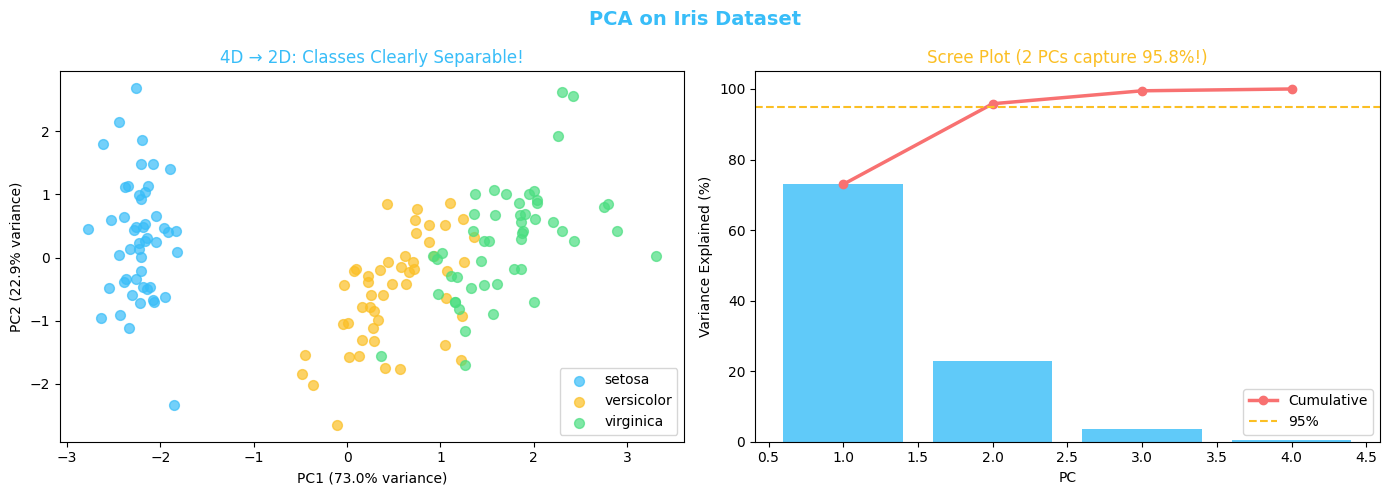

In [49]:
# ── PCA on real data: Iris dataset ────────────────────────────────────
from sklearn.datasets import load_iris

BLUE   = '#38BDF8'
AMBER  = '#FBBF24'
GREEN  = '#4ADE80'
RED    = '#F87171'


iris = load_iris()
X_iris = iris.data
y_iris = iris.target
target_names = iris.target_names

scaler = StandardScaler()
X_std_iris = scaler.fit_transform(X_iris)

pca_iris = PCA()
X_pca_iris = pca_iris.fit_transform(X_std_iris)

print("Iris Dataset — PCA Results")
print(f"Original dimensions: {X_iris.shape[1]}")
print(f"Variance explained per component:")
for i, v in enumerate(pca_iris.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:.1f}%  (cumulative: {pca_iris.explained_variance_ratio_[:i+1].sum()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA on Iris Dataset', fontsize=14, color=BLUE, fontweight='bold')

colors_iris = [BLUE, AMBER, GREEN]
for class_idx, (color, name) in enumerate(zip(colors_iris, target_names)):
    mask_i = y_iris == class_idx
    axes[0].scatter(X_pca_iris[mask_i, 0], X_pca_iris[mask_i, 1],
                    color=color, alpha=0.7, s=50, label=name)
axes[0].set_xlabel(f'PC1 ({pca_iris.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca_iris.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('4D → 2D: Classes Clearly Separable!', color=BLUE)
axes[0].legend()

# Scree
axes[1].bar(range(1, 5), pca_iris.explained_variance_ratio_*100, color=BLUE, alpha=0.8)
axes[1].plot(range(1, 5), np.cumsum(pca_iris.explained_variance_ratio_*100),
             'o-', color=RED, lw=2.5, label='Cumulative')
axes[1].axhline(95, color=AMBER, lw=1.5, linestyle='--', label='95%')
axes[1].set_xlabel('PC'); axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Scree Plot (2 PCs capture 95.8%!)', color=AMBER)
axes[1].legend()

plt.tight_layout()
plt.show()

Vocabulary: ['algorithms', 'baking', 'cake', 'chocolate', 'classification', 'cleaning', 'clustering', 'cooking', 'data', 'dessert', 'feature', 'mining', 'normalization', 'preprocessing', 'recipes', 'selection', 'sweet', 'transformation']


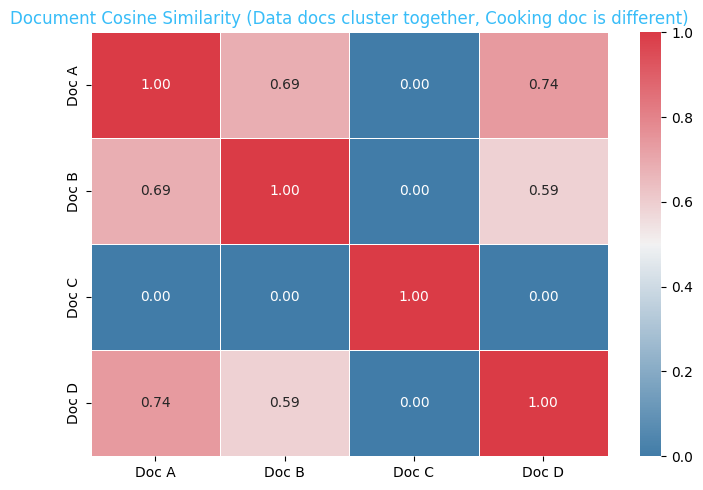

  Doc A ↔ Doc B: 0.686
  Doc A ↔ Doc C: 0.000
  Doc A ↔ Doc D: 0.740
  Doc B ↔ Doc C: 0.000
  Doc B ↔ Doc D: 0.589
  Doc C ↔ Doc D: 0.000


In [50]:
# ── Cosine similarity: document comparison ────────────────────────────
from collections import Counter
import re

docs = {
    'Doc A': "data mining preprocessing data cleaning data transformation",
    'Doc B': "data mining clustering classification data algorithms",
    'Doc C': "cooking recipes baking chocolate cake sweet dessert",
    'Doc D': "data preprocessing normalization data mining feature selection",
}

# Build vocabulary
all_words = sorted(set(w for d in docs.values() for w in d.split()))
print("Vocabulary:", all_words)

# TF vectors
def tf_vector(doc, vocab):
    counts = Counter(doc.split())
    return np.array([counts.get(w, 0) for w in vocab], dtype=float)

vecs = {name: tf_vector(text, all_words) for name, text in docs.items()}

def cosine_sim(v1, v2):
    dot = np.dot(v1, v2)
    norms = np.linalg.norm(v1) * np.linalg.norm(v2)
    return dot / norms if norms > 0 else 0.0

names = list(vecs.keys())
n = len(names)
sim_mat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_mat[i,j] = cosine_sim(vecs[names[i]], vecs[names[j]])

fig, ax = plt.subplots(figsize=(7,5))
cmap = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(sim_mat, annot=True, fmt='.2f', cmap=cmap,
            xticklabels=names, yticklabels=names,
            ax=ax, linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Document Cosine Similarity (Data docs cluster together, Cooking doc is different)',
             color=BLUE, fontsize=12)
plt.tight_layout()
plt.show()

for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        if i < j:
            print(f"  {n1} ↔ {n2}: {sim_mat[i,j]:.3f}")